# Commit-Level Bug Detection — Inference Methods on the Full KG

This notebook evaluates **every** inference method on the finalized KG-Commit
graph (all 8,059 ApacheJIT-labelled apache/groovy commits) and compares them.

All methods are **CPU-only / GNN-free** and evaluated in two protocols:
* **OFFLINE** — a single time-ordered 70/30 split (train on older commits).
* **ONLINE (prequential)** — predict each commit from the *past only*, then
  learn it (the correct just-in-time protocol; expanding-window refit).

Methods: classic JIT metrics, relational priors (wvRN), structural TF-IDF over
AST-change tokens, Personalized PageRank propagation, KG embeddings
(Truncated-SVD/LSA, node2vec, TransE, DistMult), and an early **Fusion**.

The heavy work (feature extraction, embedding training) is done once by
`inference/run_all.py` and cached; this notebook just loads and visualises it.

In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT/'inference').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT/'inference'))
print('repo root:', ROOT)

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve
sns.set_theme(style='whitegrid'); plt.rcParams['figure.dpi']=110

import run_all
results = run_all.evaluate_all()        # loads cached results (fast)
split = results['split']
print(f"commits={split['Nc']}  offline test bug-rate={split['test_bug']:.3f}  "
      f"online bug-rate={split['online_bug']:.3f}")

repo root: C:\Users\sinab\Documents\GitHub\KG-Commit


commits=8059  offline test bug-rate=0.163  online bug-rate=0.245


## 1. Results table (offline vs online)

In [2]:
def to_df(d):
    return pd.DataFrame({k: v['metrics'] for k, v in d.items()}).T[['ROC_AUC','PR_AUC','F1','MCC']]
off = to_df(results['offline']).add_suffix('_off')
on  = to_df(results['online']).add_suffix('_on')
comp = off.join(on).sort_values('PR_AUC_on', ascending=False)
order = comp.index.tolist()
comp.round(3)

,ROC_AUC_off,PR_AUC_off,F1_off,MCC_off,ROC_AUC_on,PR_AUC_on,F1_on,MCC_on
Fusion,0.820,0.542,0.477,0.376,0.827,0.616,0.555,0.397
TFIDF,0.731,0.404,0.395,0.256,0.750,0.489,0.519,0.333
DistMult,0.768,0.438,0.437,0.317,0.757,0.487,0.529,0.343
node2vec,0.749,0.405,0.399,0.264,0.740,0.471,0.506,0.306
TransE,0.726,0.360,0.386,0.247,0.730,0.469,0.497,0.292
wvRN-priors,0.787,0.408,0.081,0.127,0.733,0.460,0.067,0.115
KGE-SVD,0.691,0.306,0.382,0.234,0.703,0.442,0.460,0.279
JIT-metrics,0.739,0.355,0.411,0.280,0.679,0.398,0.453,0.218
PPR,0.687,0.273,0.338,0.170,0.681,0.351,0.471,0.245


## 2. Headline comparison — PR-AUC and ROC-AUC

PR-AUC is the most informative metric under class imbalance (~20% buggy). The
dashed line is the trivial random baseline (= the positive rate).

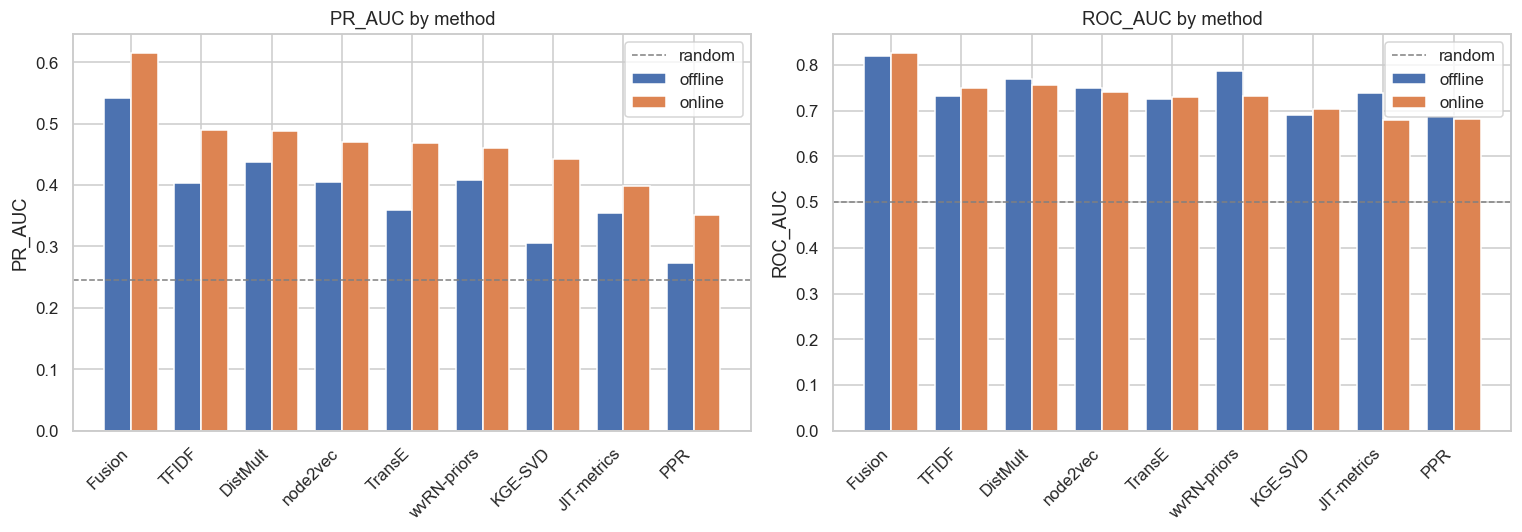

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
x = np.arange(len(order)); wdt = 0.38
for ax, metric, rnd in [(axes[0],'PR_AUC',split['online_bug']), (axes[1],'ROC_AUC',0.5)]:
    ax.bar(x-wdt/2, [results['offline'][m]['metrics'][metric] for m in order], wdt, label='offline')
    ax.bar(x+wdt/2, [results['online'][m]['metrics'][metric] for m in order], wdt, label='online')
    ax.axhline(rnd, ls='--', c='gray', lw=1, label='random')
    ax.set_xticks(x); ax.set_xticklabels(order, rotation=45, ha='right')
    ax.set_ylabel(metric); ax.set_title(metric+' by method'); ax.legend()
plt.tight_layout(); plt.show()

## 3. F1 and MCC (decision-threshold metrics at 0.5)

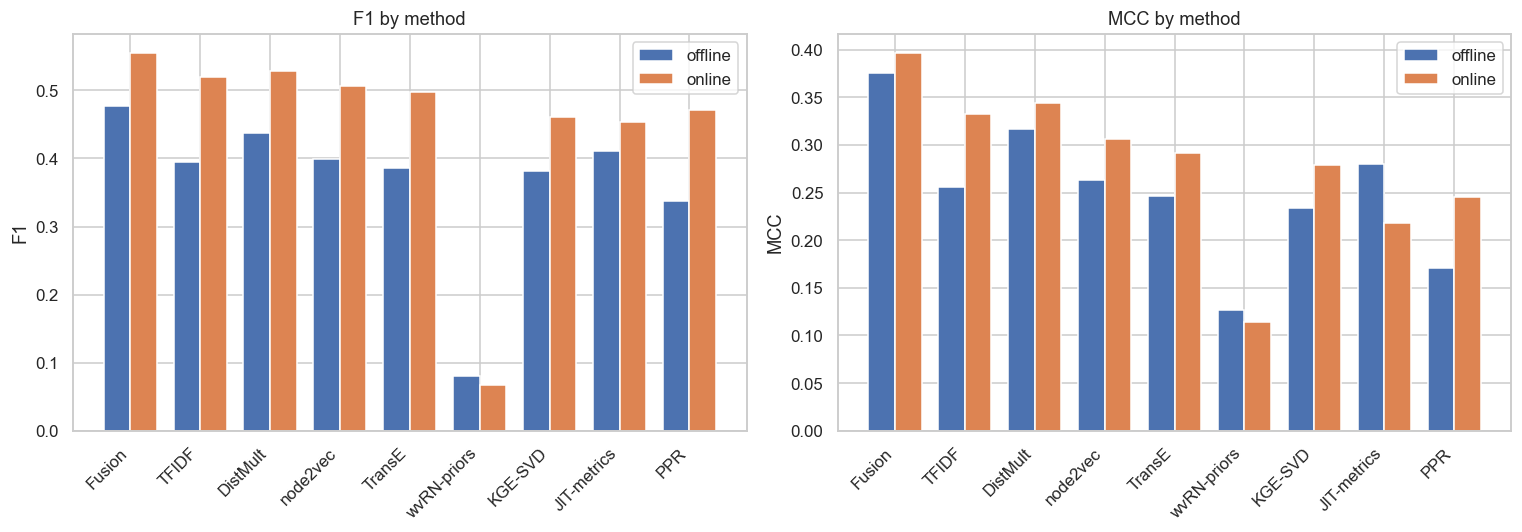

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
for ax, metric in [(axes[0],'F1'), (axes[1],'MCC')]:
    ax.bar(x-wdt/2, [results['offline'][m]['metrics'][metric] for m in order], wdt, label='offline')
    ax.bar(x+wdt/2, [results['online'][m]['metrics'][metric] for m in order], wdt, label='online')
    ax.set_xticks(x); ax.set_xticklabels(order, rotation=45, ha='right')
    ax.set_ylabel(metric); ax.set_title(metric+' by method'); ax.legend()
plt.tight_layout(); plt.show()

## 4. ROC and Precision–Recall curves (online / prequential)

The full curves, not just the summary numbers — the fairest visual comparison.

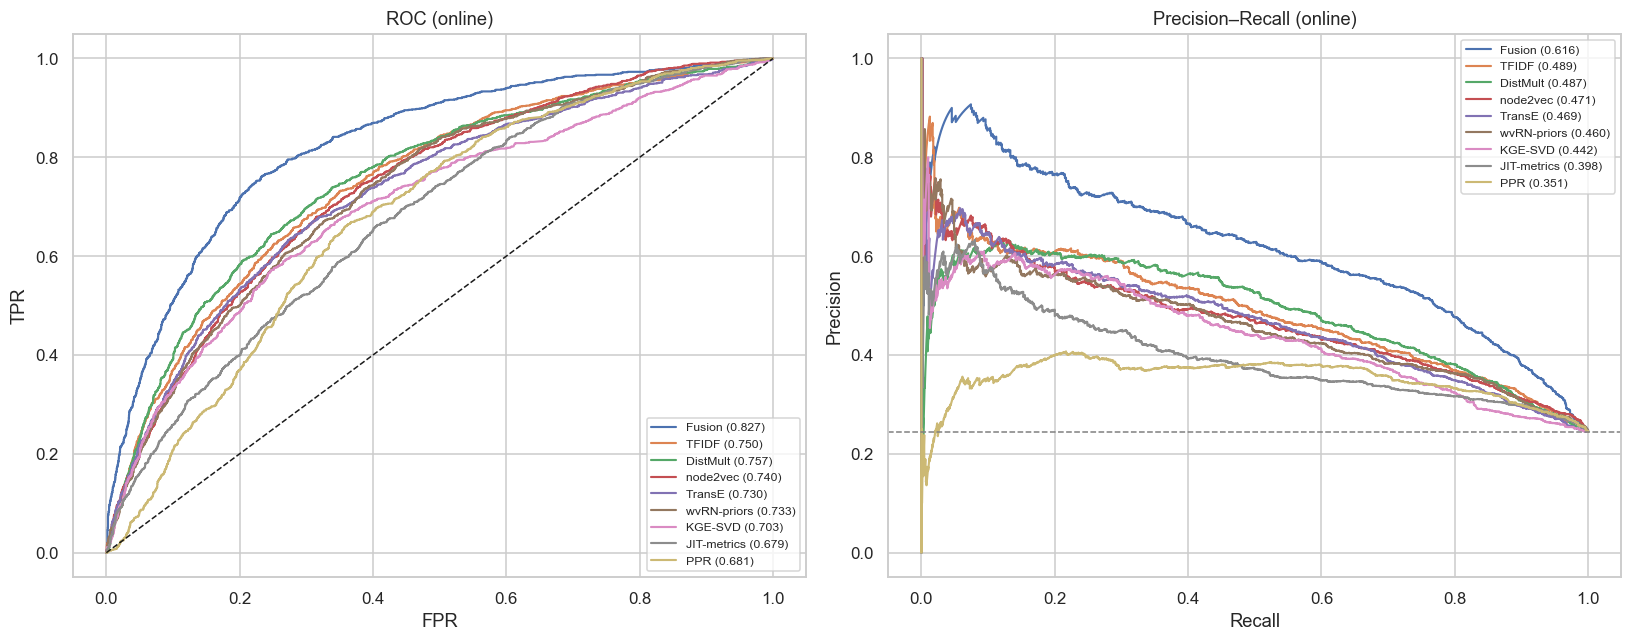

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))
for m in order:
    d = results['online'][m]
    fpr, tpr, _ = roc_curve(d['y'], d['p'])
    axes[0].plot(fpr, tpr, lw=1.4, label=f"{m} ({d['metrics']['ROC_AUC']:.3f})")
    pr, rc, _ = precision_recall_curve(d['y'], d['p'])
    axes[1].plot(rc, pr, lw=1.4, label=f"{m} ({d['metrics']['PR_AUC']:.3f})")
axes[0].plot([0,1],[0,1],'k--',lw=1); axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC (online)')
axes[0].legend(fontsize=8, loc='lower right')
axes[1].axhline(split['online_bug'], ls='--', c='gray', lw=1)
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision–Recall (online)')
axes[1].legend(fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()

## 5. Metric heatmap (online)

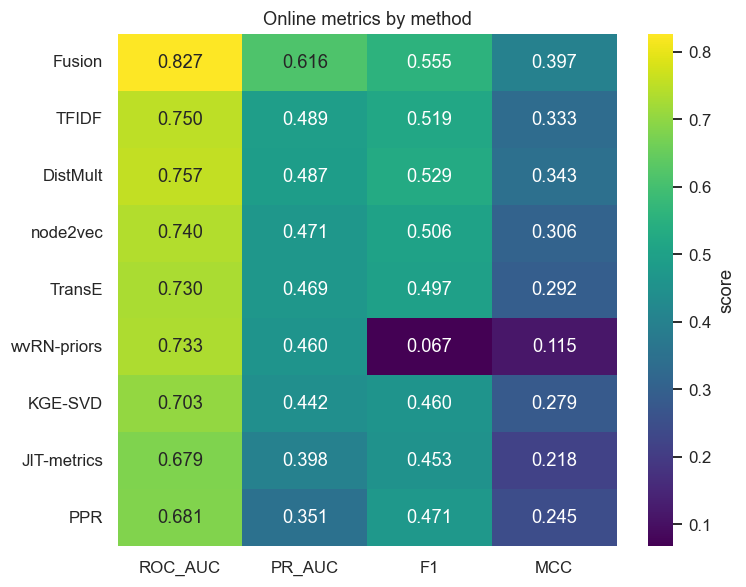

In [6]:
hm = pd.DataFrame({m: results['online'][m]['metrics'] for m in order}).T[['ROC_AUC','PR_AUC','F1','MCC']]
plt.figure(figsize=(7, 0.5*len(order)+1))
sns.heatmap(hm, annot=True, fmt='.3f', cmap='viridis', cbar_kws={'label':'score'})
plt.title('Online metrics by method'); plt.tight_layout(); plt.show()

## 6. Ranking and the value of KG features

Methods ranked by online PR-AUC. We also compute the **lift of Fusion over the
JIT-metrics baseline** — the core question: do the KG's AST/graph signals help?

In [7]:
rank = comp[['PR_AUC_on','ROC_AUC_on','F1_on','MCC_on']].round(3)
display(rank)
base = results['online']['JIT-metrics']['metrics']['PR_AUC']
best = comp['PR_AUC_on'].max(); best_m = comp['PR_AUC_on'].idxmax()
print(f"Best online method: {best_m}  (PR-AUC {best:.3f})")
print(f"JIT-metrics baseline PR-AUC: {base:.3f}")
print(f"Lift of best over baseline: {100*(best-base)/base:+.0f}% relative")

,PR_AUC_on,ROC_AUC_on,F1_on,MCC_on
Fusion,0.616,0.827,0.555,0.397
TFIDF,0.489,0.750,0.519,0.333
DistMult,0.487,0.757,0.529,0.343
node2vec,0.471,0.740,0.506,0.306
TransE,0.469,0.730,0.497,0.292
wvRN-priors,0.460,0.733,0.067,0.115
KGE-SVD,0.442,0.703,0.460,0.279
JIT-metrics,0.398,0.679,0.453,0.218
PPR,0.351,0.681,0.471,0.245


Best online method: Fusion  (PR-AUC 0.616)
JIT-metrics baseline PR-AUC: 0.398
Lift of best over baseline: +54% relative


## 7. Why it works — the KG bug signal

Two structural facts that make the graph useful: buggy commits make **larger AST
changes**, and the **bug rate drifts over time** (motivating online evaluation).

C:\Users\sinab\AppData\Local\Temp\ipykernel_36712\4214306935.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([np.log1p(dg), np.log1p(db)], labels=['benign','buggy'], showfliers=False)
C:\Users\sinab\AppData\Local\Temp\ipykernel_36712\4214306935.py:7: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  yrs = np.array([datetime.datetime.utcfromtimestamp(int(t)).year for t in meta['author_ts']])


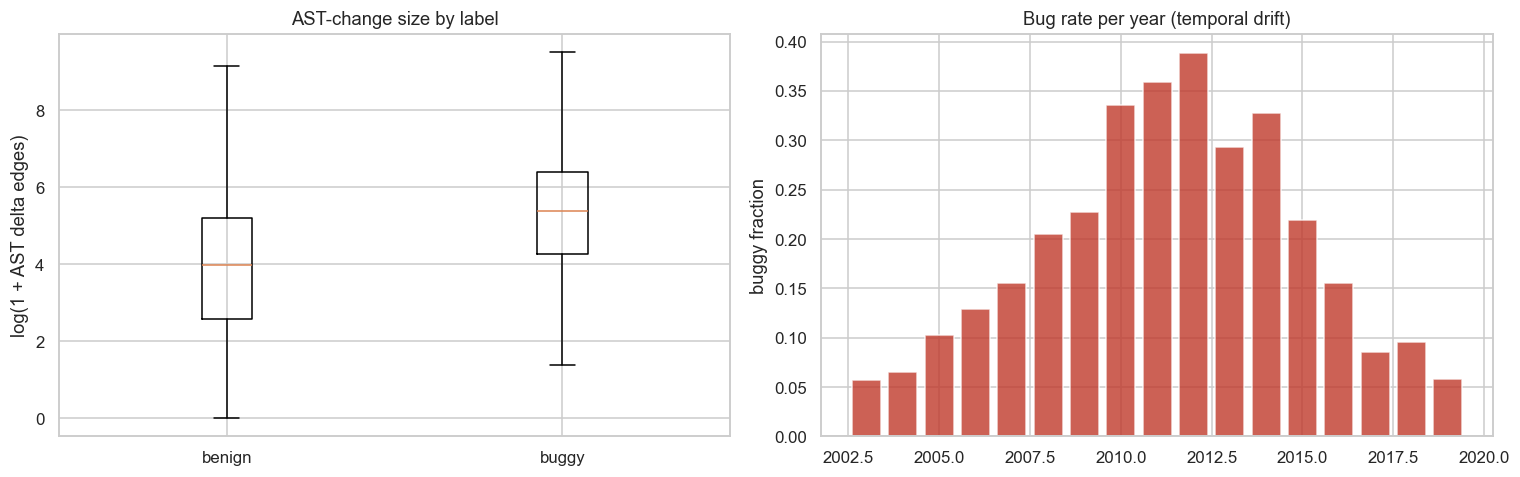

median delta edges  benign=53  buggy=216


In [8]:
import datetime
meta = results['meta']
fig, axes = plt.subplots(1, 2, figsize=(14,4.5))
db = meta['delta_total'][meta['buggy']==1]; dg = meta['delta_total'][meta['buggy']==0]
axes[0].boxplot([np.log1p(dg), np.log1p(db)], labels=['benign','buggy'], showfliers=False)
axes[0].set(ylabel='log(1 + AST delta edges)', title='AST-change size by label')
yrs = np.array([datetime.datetime.utcfromtimestamp(int(t)).year for t in meta['author_ts']])
dfp = pd.DataFrame({'year':yrs,'buggy':meta['buggy']}).groupby('year').buggy.mean()
axes[1].bar(dfp.index, dfp.values, color='#c0392b', alpha=0.8)
axes[1].set(ylabel='buggy fraction', title='Bug rate per year (temporal drift)')
plt.tight_layout(); plt.show()
print(f"median delta edges  benign={np.median(dg):.0f}  buggy={np.median(db):.0f}")

## 8. Conclusions

* **Fusion of KG-native signals with JIT metrics is the strongest** model in the
  online (prequential) setting, clearly beating the JIT-metrics-only baseline —
  the AST/delta layers add real predictive value for commit-level bug detection.
* Among single KG methods, **structural TF-IDF** and **DistMult embeddings** are
  the most competitive; relational priors (wvRN) are a strong cheap baseline.
* All of this is **CPU-only, no GNN** — a practical inference path for the
  resource budget, and a baseline to beat if a GNN is added later.

*Reproduce:* `python inference/run_all.py` (rebuilds the cache), then re-run this
notebook. Per-method code lives in `inference/` (`train_eval.py`,
`advanced_infer.py`, `online_infer.py`, `kge_infer.py`).